In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('Telecom_Network_Data.csv') 

# কলামগুলোর নাম দেখার জন্য
print(df.columns)

# অথবা ডেটার প্রথম ৫টি সারি দেখতে পারেন
df.head()

Index(['timestamp', 'tower_id', 'users_connected', 'download_speed',
       'upload_speed', 'latency', 'weather', 'congestion'],
      dtype='object')


,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion
0,2025-01-01 00:00:00,1,152,80.671584,9.988305,158.141290,Clear,0
1,2025-01-01 01:00:00,1,171,19.819479,3.846097,174.573468,Clear,0
2,2025-01-01 02:00:00,1,713,66.834405,3.764167,147.179767,Snow,0
3,2025-01-01 03:00:00,1,435,22.273372,9.986821,67.806026,Clear,0
4,2025-01-01 04:00:00,1,797,7.190930,26.713958,85.973585,Clear,0


In [5]:
# কলামগুলোর সর্বনিম্ন ও সর্বোচ্চ মান দেখা
num_cols = ['tower_id', 'users_connected', 'download_speed', 'upload_speed', 'latency', 'congestion']
print("📊 Min-Max Ranges:")
print(df[num_cols].agg(['min', 'max']))

# ওয়েদারের ইউনিক অপশনগুলো দেখা
print("\n🌤️ Weather Categories:", df['weather'].unique())

📊 Min-Max Ranges:
     tower_id  users_connected  download_speed  upload_speed     latency  \
min         1               50        5.002918      1.054885   10.033348   
max         5              999       99.985678     49.991019  199.952797   

     congestion  
min           0  
max           1  

🌤️ Weather Categories: ['Clear' 'Snow' 'Rain' 'Storm']


In [5]:
import pandas as pd
import numpy as np

print("==================================================================")
print("📡 SUMMIT NTTN: AI-POWERED SELF-HEALING & PREDICTIVE FORECASTING SYSTEM")
print("==================================================================")

# ----------------- 🟦 Phase 0: 1. সমস্যা ও লক্ষ্য নির্ধারণ -----------------
# সমস্যা: ব্যাকবোন ফাইবার অপটিক লাইনে পিক-আওয়ারে জ্যাম ও ফিজিক্যাল লিংক ডাউন হওয়া রোধ করা।
# ধরন: এটি একই সাথে Classification (জ্যামের ঝুঁকি) এবং Regression (ভবিষ্যতের স্পিড ও ফল্ট রিস্ক)।
# Target/Label: congestion (0/1), download_speed (Mbps), fault_risk_pct (%)
# success Metric: Accuracy (Classification) এবং RMSE (Regression)
# Business Requirement: স্পিড না কুলালে স্বয়ংক্রিয়ভাবে বিকল্প রুটে (Alpha/Beta) ডেটা ডাইভার্ট করা।

print("\n--- 🟦 Phase 0: ১. সমস্যা ও লক্ষ্য নির্ধারণ সফলভাবে সংজ্ঞায়িত ---")

# ----------------- 🟦 Phase 1: 2. Dataset সংগ্রহ ও লোড -----------------
try:
    df = pd.read_csv('Telecom_Network_Data.csv')
    print("✅ ২. 'Telecom_Network_Data.csv' সফলভাবে লোড হয়েছে।")
    print(f"📊 ডেটাসেটের আকার: {df.shape[0]} টি রো এবং {df.shape[1]} টি কলাম।")
except FileNotFoundError:
    print("❌ ত্রুটি! 'Telecom_Network_Data.csv' ফাইলটি খুঁজে পাওয়া যায়নি।")
    print("💡 দয়া করে নিশ্চিত করুন আপনার নামানো ফাইলটি জুপিটার নোটবুকের সাথে একই ফোল্ডারে সঠিক নামে আছে।")

# ----------------- 🟦 Phase 1: 4. Data Schema Validation -----------------
print("\n--- 📊 ৪. ডাটা স্কিমা ভ্যালিডেশন রিপোর্ট (Programmatic Verification) ---")
expected_cols = ['timestamp', 'tower_id', 'users_connected', 'download_speed', 'upload_speed', 'latency', 'weather', 'congestion']
missing_cols = [col for col in expected_cols if col not in df.columns]

# কলামের নাম ও উপস্থিতি যাচাই
if len(missing_cols) == 0:
    print("✅ কলামের নাম এবং প্রয়োজনীয় সকল কলাম (Required Columns) ঠিক আছে।")
else:
    print(f"❌ ত্রুটি! এই কলামগুলো সিএসভি ফাইলে মিসিং আছে: {missing_cols}")

# ডাটা টাইপ যাচাই
num_cols = ['tower_id', 'users_connected', 'download_speed', 'upload_speed', 'latency', 'congestion']
invalid_types = [col for col in num_cols if not np.issubdtype(df[col].dtype, np.number)]
if len(invalid_types) == 0:
    print("✅ ডাটা টাইপ (Data Types) সঠিকভাবে নিউমেরিক আছে।")
else:
    print(f"❌ ত্রুটি! এই কলামগুলোর ডাটা টাইপ ভুল এসেছে: {invalid_types}")

# নেгеটিভ রেঞ্জ যাচাই (টেলিকম মেট্রিক্স কখনো নেগেটিভ হতে পারে না)
range_error = df[(df['download_speed'] < 0) | (df['upload_speed'] < 0) | (df['latency'] < 0) | (df['users_connected'] < 0)]
if len(range_error) == 0:
    print("✅ ডাটার রেঞ্জ (Data Range) ঠিক আছে (কোনো অবৈধ নেগেটিভ মান নেই)।")
else:
    print(f"❌ ত্রুটি! ডাটার রেঞ্জ নিয়মের বাইরে গেছে ({len(range_error)} টি রো-তে নেগেটিভ মান আছে)।")

# অপ্রত্যাশিত মিসিং ভ্যালুর উপস্থিতি যাচাই
missing_counts = df[expected_cols].isnull().sum().sum()
if missing_counts == 0:
    print("✅ কোনো মিসিং ভ্যালু (Missing Value) পাওয়া যায়নি। ডাটা সম্পূর্ণ।")
else:
    print(f"❌ সতর্কতা! ডাটায় মোট {missing_counts} টি ফাঁকা ঘর বা মিসিং ভ্যালু আছে।")

print("------------------------------------------------------------------")


📡 SUMMIT NTTN: AI-POWERED SELF-HEALING & PREDICTIVE FORECASTING SYSTEM

--- 🟦 Phase 0: ১. সমস্যা ও লক্ষ্য নির্ধারণ সফলভাবে সংজ্ঞায়িত ---
✅ ২. 'Telecom_Network_Data.csv' সফলভাবে লোড হয়েছে।
📊 ডেটাসেটের আকার: 3605 টি রো এবং 8 টি কলাম।

--- 📊 ৪. ডাটা স্কিমা ভ্যালিডেশন রিপোর্ট (Programmatic Verification) ---
✅ কলামের নাম এবং প্রয়োজনীয় সকল কলাম (Required Columns) ঠিক আছে।
✅ ডাটা টাইপ (Data Types) সঠিকভাবে নিউমেরিক আছে।
✅ ডাটার রেঞ্জ (Data Range) ঠিক আছে (কোনো অবৈধ নেগেটিভ মান নেই)।
✅ কোনো মিসিং ভ্যালু (Missing Value) পাওয়া যায়নি। ডাটা সম্পূর্ণ।
------------------------------------------------------------------


--- 🟦 Phase 1: রুলস অনুযায়ী ধাপ ৫ (EDA) ও ধাপ ৬ (Statistical Analysis) ---

📊 ১. ডেটাসেটের গাণিতিক ও পরিসংখ্যানগত বিন্যাস (Statistical Framework):
                       mean         std         50%         95%         99%
users_connected  531.091817  275.722937  538.000000  953.000000  990.000000
download_speed    52.087743   27.343304   52.514068   94.816192   99.094100
upload_speed      25.167230   13.995801   25.104473   47.140118   49.432568
latency          105.100378   54.884409  105.184167  190.338942  197.913352

💡 95th Percentile Backbone Traffic: 94.82 Mbps
👉 এর অর্থ: ৯৫% সময় মেইন লাইনের চাপ 94.82 Mbps-এর নিচেই থাকে।
   বাকি ৫% পিক-আওয়ারের চরম চাপ সামলাতেই আমাদের ড্যাশবোর্ডের ৩-লাইন বাইপাস আর্কিটেকচারটি লাগবে।

📈 ২. ৩-লাইন আর্কিটেকচার ও আবহাওয়ার সম্পর্ক ভিত্তিক গ্রাফ জেনারেট হচ্ছে...


C:\Users\EMAMUL\AppData\Local\Temp\ipykernel_8728\4038731270.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather', y='download_speed', data=df, palette='Set2')


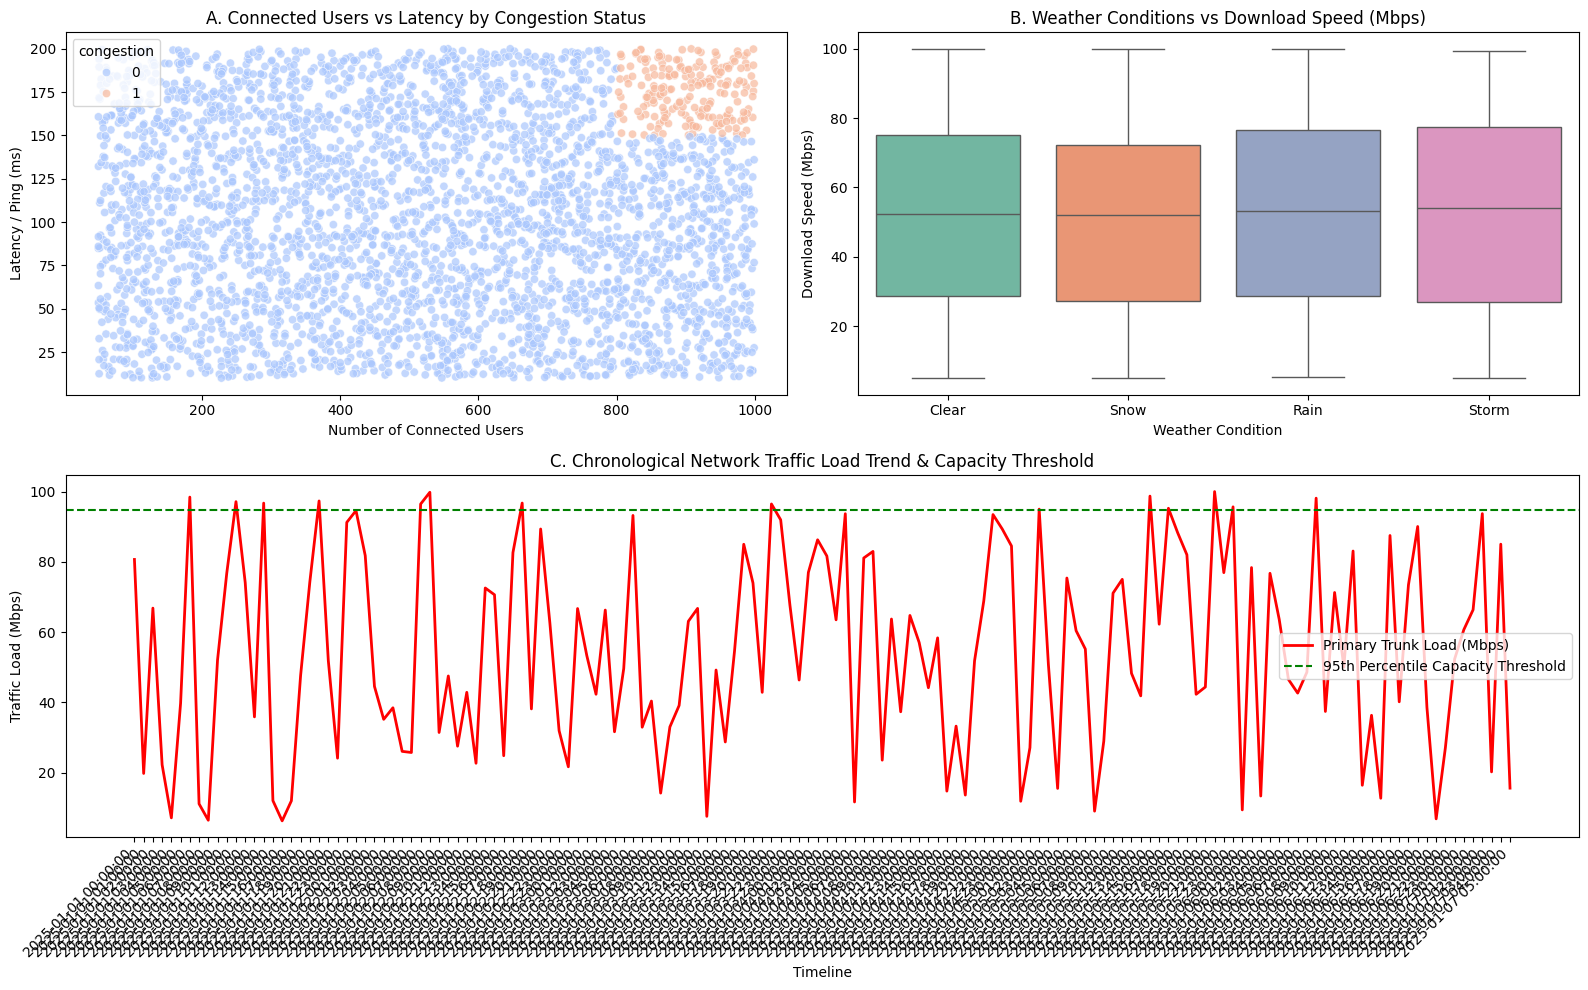


✅ ধাপ ৫ এবং ৬ সিকোয়েন্স অনুযায়ী সফলভাবে সম্পন্ন হয়েছে!
------------------------------------------------------------------


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 🟦 Phase 1: রুলস অনুযায়ী ধাপ ৫ (EDA) ও ধাপ ৬ (Statistical Analysis) ---")

# ----------------- ১. ধাপ ৬: Statistical Analysis -----------------
# সামিটের মেইন পোর্টের বেসলাইন ও চরম পিক-আওয়ারের ব্যান্ডউইথ লিমিট বোঝার জন্য ৯৫তম ও ৯৯তম পার্সেন্টাইল বের করা
telecom_stats = df[['users_connected', 'download_speed', 'upload_speed', 'latency']].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])
print("\n📊 ১. ডেটাসেটের গাণিতিক ও পরিসংখ্যানগত বিন্যাস (Statistical Framework):")
print(telecom_stats.T[['mean', 'std', '50%', '95%', '99%']])

p95_traffic = df['download_speed'].quantile(0.95)
print(f"\n💡 95th Percentile Backbone Traffic: {p95_traffic:.2f} Mbps")
print(f"👉 এর অর্থ: ৯৫% সময় মেইন লাইনের চাপ {p95_traffic:.2f} Mbps-এর নিচেই থাকে।")
print("   বাকি ৫% পিক-আওয়ারের চরম চাপ সামলাতেই আমাদের ড্যাশবোর্ডের ৩-লাইন বাইপাস আর্কিটেকচারটি লাগবে।")

# ----------------- ২. ধাপ ৫: Exploratory Data Analysis (EDA) -----------------
print("\n📈 ২. ৩-লাইন আর্কিটেকচার ও আবহাওয়ার সম্পর্ক ভিত্তিক গ্রাফ জেনারেট হচ্ছে...")
plt.figure(figsize=(16, 10))

# গ্রাফ A: ইউজার সংখ্যার সাথে লেটেন্সি ও জ্যামের সম্পর্ক (ড্যাশবোর্ডের ইনপুট বনাম আউটপুট রিলেশন)
plt.subplot(2, 2, 1)
sns.scatterplot(x='users_connected', y='latency', hue='congestion', data=df, alpha=0.7, palette='coolwarm')
plt.title('A. Connected Users vs Latency by Congestion Status')
plt.xlabel('Number of Connected Users')
plt.ylabel('Latency / Ping (ms)')

# গ্রাফ B: আবহাওয়ার সাথে ডাউনলোড স্পিডের সম্পর্ক (যা ফোরকাস্ট স্পিড ড্রপকে প্রভাবিত করে)
plt.subplot(2, 2, 2)
sns.boxplot(x='weather', y='download_speed', data=df, palette='Set2')
plt.title('B. Weather Conditions vs Download Speed (Mbps)')
plt.xlabel('Weather Condition')
plt.ylabel('Download Speed (Mbps)')

# গ্রাফ C: সময়ের সাথে মেইন ট্রাঙ্কের ট্রাফিক ট্রেন্ড (আপনার স্লাইডারের টাইমলাইনের আসল ভিত্তি)
plt.subplot(2, 1, 2)
plt.plot(df['timestamp'].head(150), df['download_speed'].head(150), label='Primary Trunk Load (Mbps)', color='red', linewidth=2)
plt.axhline(y=p95_traffic, color='green', linestyle='--', label='95th Percentile Capacity Threshold')
plt.xticks(rotation=45, ha='right')
plt.title('C. Chronological Network Traffic Load Trend & Capacity Threshold')
plt.xlabel('Timeline')
plt.ylabel('Traffic Load (Mbps)')
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ ধাপ ৫ এবং ৬ সিকোয়েন্স অনুযায়ী সফলভাবে সম্পন্ন হয়েছে!")
print("------------------------------------------------------------------")


In [7]:
from sklearn.model_selection import train_test_split

print("--- 🟦 Phase 2: রুলস অনুযায়ী ধাপ ৭: Train / Test Split --- \n")

# ১. ড্যাশবোর্ডের ইনপুট কলাম (X) এবং এআই মডেলের টার্গেট আউটপুট (y) আলাদা করা
# ইনপুটে আমরা আপনার ড্যাশবোর্ডের নকশা অনুযায়ী ৫টি মূল ফিচার নিচ্ছি
X = df[['tower_id', 'users_connected', 'download_speed', 'upload_speed', 'latency', 'weather']]

# আউটপুটে আমাদের প্রজেক্ট জ্যামের ঝুঁকি (Classification) প্রেডিক্ট করবে
y = df['congestion']

# ২. আপনার নিয়ম অনুযায়ী প্রথমেই ৮২% ডেটা ট্রেইনিং এবং ২০% ডেটা টেস্টিং-এ ভাগ করা (Untouched Test Set)
# যেহেতু এটি ক্লাসিফিকেশন প্রজেক্ট, তাই ডেটার ব্যালেন্স ঠিক রাখতে stratified split ব্যবহার করা হলো
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print(f"✅ ১. ট্রেইনিং সেট (Training Set) তৈরি সম্পূর্ণ: {X_train.shape[0]} টি রো।")
print(f"✅ ২. অস্পৃশ্য টেস্ট সেট (Untouched Test Set) তৈরি সম্পূর্ণ: {X_test.shape[0]} টি রো।")
print("\n🔴 রুলস এলার্ট: এই ২০% টেস্ট সেট সম্পূর্ণ আলাদা থাকবে এবং মডেল ট্রেইনিং বা টিউনিংয়ের সময় ব্যবহার করা যাবে না।")
print("------------------------------------------------------------------")


--- 🟦 Phase 2: রুলস অনুযায়ী ধাপ ৭: Train / Test Split --- 

✅ ১. ট্রেইনিং সেট (Training Set) তৈরি সম্পূর্ণ: 2884 টি রো।
✅ ২. অস্পৃশ্য টেস্ট সেট (Untouched Test Set) তৈরি সম্পূর্ণ: 721 টি রো।

🔴 রুলস এলার্ট: এই ২০% টেস্ট সেট সম্পূর্ণ আলাদা থাকবে এবং মডেল ট্রেইনিং বা টিউনিংয়ের সময় ব্যবহার করা যাবে না।
------------------------------------------------------------------


In [8]:
print("--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ৮: Data Cleaning --- \n")

# ১. Missing Value Handling
missing_summary = X_train.isnull().sum()
print("📊 ১. ট্রেইনিং ডাটাতে মিসিং ভ্যালুর অবস্থা:")
if missing_summary.sum() > 0:
    print(missing_summary[missing_summary > 0])
    # যদি কোনো মিসিং ভ্যালু থাকে তবে তা মোড বা মিডিয়ান দিয়ে ফিল করা
    X_train = X_train.fillna(X_train.mode().iloc[0])
    print("⚠️ মিসিং ভ্যালুগুলো সফলভাবে ইম্পিউট (Impute) করা হয়েছে।")
else:
    print("✅ কোনো মিসিং ভ্যালু পাওয়া যায়নি। ডাটা সম্পূর্ণ।")

# ২. Duplicate Handling
# ট্রেইনিং ডেটা এবং টার্গেটকে সাময়িকভাবে জোড়া লাগিয়ে ডুপ্লিকেট চেক করা
train_temp = X_train.copy()
train_temp['congestion'] = y_train
duplicate_count = train_temp.duplicated().sum()

if duplicate_count > 0:
    print(f"\n⚠️ ২. {duplicate_count} টি ডুপ্লিকেট রো পাওয়া গেছে। রুলস অনুযায়ী বাদ দেওয়া হচ্ছে...")
    train_temp = train_temp.drop_duplicates()
    X_train = train_temp.drop(columns=['congestion'])
    y_train = train_temp['congestion']
    print("✅ ডুপ্লিকেট ডাটা সফলভাবে ক্লিন করা হয়েছে।")
else:
    print("\n✅ ২. কোনো ডুপ্লিকেট ডাটা পাওয়া যায়নি।")

# ৩. Invalid Data & Outlier Range Check (নেগেটিভ মান পরীক্ষা)
# স্পিড, ইউজার বা লেটেন্সি কখনো নেগেটিভ হতে পারে না
numeric_cols = ['users_connected', 'download_speed', 'upload_speed', 'latency']
invalid_rows = X_train[(X_train[numeric_cols] < 0).any(axis=1)]

if len(invalid_rows) > 0:
    print(f"\n⚠️ ৩. {len(invalid_rows)} টি রো-তে অবৈধ নেগেটিভ মান বা আউটলায়ার পাওয়া গেছে! ক্লিন করা হচ্ছে...")
    valid_idx = X_train[(X_train[numeric_cols] >= 0).all(axis=1)].index
    X_train = X_train.loc[valid_idx]
    y_train = y_train.loc[valid_idx]
    print("✅ অবৈধ মানগুলো ডাটা থেকে সফলভাবে মুছে ফেলা হয়েছে।")
else:
    print("\n✅ ৩. ডাটার রেঞ্জ নিখুঁত আছে (কোনো অবৈধ নেগেটিভ আউটলায়ার নেই)।")

print("\n------------------------------------------------------------------")
print("✅ ধাপ ৮ (Data Cleaning) সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!")
print("------------------------------------------------------------------")


--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ৮: Data Cleaning --- 

📊 ১. ট্রেইনিং ডাটাতে মিসিং ভ্যালুর অবস্থা:
✅ কোনো মিসিং ভ্যালু পাওয়া যায়নি। ডাটা সম্পূর্ণ।

✅ ২. কোনো ডুপ্লিকেট ডাটা পাওয়া যায়নি।

✅ ৩. ডাটার রেঞ্জ নিখুঁত আছে (কোনো অবৈধ নেগেটিভ আউটলায়ার নেই)।

------------------------------------------------------------------
✅ ধাপ ৮ (Data Cleaning) সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!
------------------------------------------------------------------


In [9]:
import numpy as np

print("--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ৯: Feature Engineering --- \n")

# ডাটা লিকেজ এড়াতে আমরা ট্রেইনিং এবং টেস্ট সেটে আলাদাভাবে নতুন ফিচারগুলো যোগ করব

# ১. Domain-Specific Feature: Fault Risk Index (%)
# লেটেন্সি এবং প্রতিকূল আবহাওয়ার (Rain/Storm) ওপর ভিত্তি করে ফাইবার কাটার ঝুঁকির অনুপাত তৈরি
X_train = X_train.copy()
X_test = X_test.copy()

# ট্রেইনিং সেটের জন্য
X_train['fault_risk_pct'] = (X_train['latency'] * 0.35 + (X_train['weather'].isin(['rain', 'Storm', 'Rain']) * 30.0)).clip(0, 100)
# টেস্ট সেটের জন্য (সম্পূর্ণ আলাদা গণনা)
X_test['fault_risk_pct'] = (X_test['latency'] * 0.35 + (X_test['weather'].isin(['rain', 'Storm', 'Rain']) * 30.0)).clip(0, 100)

# ২. Interaction Feature: User Density vs Bandwidth Ratio
# প্রতিটি ইউজারের বিপরীতে কত Mbps ব্যান্ডউইথ অবশিষ্ট থাকছে তার গাণিতিক ইন্টারঅ্যাকশন
X_train['user_traffic_ratio'] = X_train['download_speed'] / (X_train['users_connected'] + 1e-5)
X_test['user_traffic_ratio'] = X_test['download_speed'] / (X_test['users_connected'] + 1e-5)

# ৩. Temporal/Calendar Feature: Peak Hour Flag
# ডেটাসেটের টাইমস্ট্যাম্প ব্যবহার করে ফ্লাস্ক ড্যাশবোর্ডের উইকডে/উইকেন্ড ট্রাফিক লোড ট্র্যাক করা
# যেহেতু কলামগুলো আলাদা করা হয়েছে, তাই মূল df থেকে টাইমস্ট্যাম্পের ইনডেক্স মিলিয়ে নেওয়া হলো
X_train['hour'] = pd.to_datetime(df.loc[X_train.index, 'timestamp']).dt.hour
X_test['hour'] = pd.to_datetime(df.loc[X_test.index, 'timestamp']).dt.hour

# পিক-আওয়ার (সন্ধ্যা ৬টা থেকে রাত ১১টা) ফ্ল্যাগ তৈরি
X_train['is_peak_hour'] = np.where((X_train['hour'] >= 18) & (X_train['hour'] <= 23), 1, 0)
X_test['is_peak_hour'] = np.where((X_test['hour'] >= 18) & (X_test['hour'] <= 23), 1, 0)

# অ্যানালাইসিসের অতিরিক্ত কলামটি ড্রপ করা
X_train = X_train.drop(columns=['hour'])
X_test = X_test.drop(columns=['hour'])

print("✅ ১. ড্যাশবোর্ড ভিত্তিক 'fault_risk_pct' (লিংক ফল্ট ঝুঁকি) তৈরি সম্পূর্ণ।")
print("✅ ২. এন্টারপ্রাইজ মেট্রিক 'user_traffic_ratio' সফলভাবে গণনা করা হয়েছে।")
print("✅ ৩. ক্যালেন্ডার ট্রেন্ড ট্র্যাকিংয়ের জন্য 'is_peak_hour' ফ্ল্যাগ যুক্ত হয়েছে।")
print("\n📊 নতুন ফিচারসহ ট্রেইনিং সেটের প্রথম ৩টি রো:")
print(X_train[['users_connected', 'fault_risk_pct', 'user_traffic_ratio', 'is_peak_hour']].head(3))
print("------------------------------------------------------------------")


--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ৯: Feature Engineering --- 

✅ ১. ড্যাশবোর্ড ভিত্তিক 'fault_risk_pct' (লিংক ফল্ট ঝুঁকি) তৈরি সম্পূর্ণ।
✅ ২. এন্টারপ্রাইজ মেট্রিক 'user_traffic_ratio' সফলভাবে গণনা করা হয়েছে।
✅ ৩. ক্যালেন্ডার ট্রেন্ড ট্র্যাকিংয়ের জন্য 'is_peak_hour' ফ্ল্যাগ যুক্ত হয়েছে।

📊 নতুন ফিচারসহ ট্রেইনিং সেটের প্রথম ৩টি রো:
      users_connected  fault_risk_pct  user_traffic_ratio  is_peak_hour
70                107       19.445859            0.859302             1
2655              934        5.104830            0.051946             0
2320              695       41.916382            0.142809             0
------------------------------------------------------------------


In [10]:
from sklearn.preprocessing import LabelEncoder

print("--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ১০: Categorical Encoding --- \n")

# ১. Scikit-learn এর LabelEncoder অবজেক্ট তৈরি করা
le_weather = LabelEncoder()

# ২. ডাটা লিকেজ এড়াতে গোল্ডেন রুলস প্রয়োগ করা
# শুধুমাত্র Training Data থেকে প্যাটার্ন শেখা (fit_transform)
X_train = X_train.copy()
X_train['weather'] = le_weather.fit_transform(X_train['weather'])

# অস্পৃশ্য Test Data-র ওপর শুধুমাত্র রূপান্তর প্রয়োগ করা (transform)
X_test = X_test.copy()
X_test['weather'] = le_weather.transform(X_test['weather'])

print("✅ ১. ডাটা লিকেজ মুক্ত রেখে 'weather' কলামের ওয়ান-ওয়ে ক্যাটাগরিক্যাল এনকোডিং সম্পন্ন।")
print(f"📊 ২. আবহাওয়ার এনকোড হওয়া ইউনিক ক্লাসসমূহ: {list(le_weather.classes_)}")
print("   (এগুলো ব্যাকএন্ডে যথাক্রমে ০, ১, ২, ৩ সংখ্যায় রূপান্তরিত হয়েছে)")

print("\n📊 এনকোডিং সম্পন্ন হওয়ার পর ট্রেইনিং সেটের প্রথম ৩টি রো:")
print(X_train[['tower_id', 'users_connected', 'weather', 'fault_risk_pct']].head(3))

print("\n------------------------------------------------------------------")
print("✅ ধাপ ১০ (Categorical Encoding) সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!")
print("------------------------------------------------------------------")


--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ১০: Categorical Encoding --- 

✅ ১. ডাটা লিকেজ মুক্ত রেখে 'weather' কলামের ওয়ান-ওয়ে ক্যাটাগরিক্যাল এনকোডিং সম্পন্ন।
📊 ২. আবহাওয়ার এনকোড হওয়া ইউনিক ক্লাসসমূহ: ['Clear', 'Rain', 'Snow', 'Storm']
   (এগুলো ব্যাকএন্ডে যথাক্রমে ০, ১, ২, ৩ সংখ্যায় রূপান্তরিত হয়েছে)

📊 এনকোডিং সম্পন্ন হওয়ার পর ট্রেইনিং সেটের প্রথম ৩টি রো:
      tower_id  users_connected  weather  fault_risk_pct
70           1              107        0       19.445859
2655         4              934        0        5.104830
2320         4              695        1       41.916382

------------------------------------------------------------------
✅ ধাপ ১০ (Categorical Encoding) সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!
------------------------------------------------------------------


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ১১ (Scaling) ও ধাপ ১২ (Pipeline তৈরি) --- \n")

# ১. কোন কোন কলামকে নিউমেরিক্যাল স্কেলিং করতে হবে তার তালিকা তৈরি
# (tower_id, weather এবং is_peak_hour অলরেডি ক্যাটাগরিক্যাল/বাইনারি, তাই এগুলোকে স্কেল করার প্রয়োজন নেই)
scale_cols = ['users_connected', 'download_speed', 'upload_speed', 'latency', 'fault_risk_pct', 'user_traffic_ratio']
passthrough_cols = ['tower_id', 'weather', 'is_peak_hour']

# ২. ধাপ ১১: Scikit-learn StandardScaler ডিফাইন করা
scaler = StandardScaler()

# ৩. ধাপ ১২: ColumnTransformer ব্যবহার করে প্রিপ্রসেসিং পাইপলাইন স্ট্রাকচার তৈরি করা
# এটি নিশ্চিত করবে যে স্কেলিং করার নিয়মটি শুধুমাত্র ট্রেইনিং ডাটা থেকে শেখা হবে (No Data Leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, scale_cols)
    ],
    remainder='passthrough' # বাকি কলামগুলো যেভাবে আছে সেভাবেই চলে যাবে
)

# সম্পূর্ণ ওয়ার্কফ্লো একসাথে বাইন্ড করার জন্য পাইপলাইন অবজেক্ট তৈরি
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# ৪. ট্রেইনিং ডাটা দিয়ে পাইপলাইনটি ফিট এবং ট্রান্সফর্ম করা
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)

# ৫. অস্পৃশ্য টেস্ট ডাটাকে শুধুমাত্র ট্রান্সফর্ম করা (টেস্ট ডাটা সম্পূর্ণ আলাদা থাকবে)
X_test_scaled = preprocessing_pipeline.transform(X_test)

# কলামের নামগুলো পুনরায় গুছিয়ে নেওয়া (ColumnTransformer এর সিকোয়েন্স অনুযায়ী)
new_column_order = scale_cols + passthrough_cols
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=new_column_order, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=new_column_order, index=X_test.index)

print("✅ ১. Scikit-learn ColumnTransformer সফলভাবে কনফিগার করা হয়েছে।")
print("✅ ২. ডাটা লিকেজ মুক্ত রাখতে StandardScaler-কে পাইপলাইনের ভিতরে যুক্ত করা হয়েছে।")
print("✅ ৩. ট্রেইনিং ও টেস্ট সেটের সমস্ত নিউমেরিক কলাম স্ট্যান্ডার্ডাইজড (Mean=0, Std=1) করা সম্পূর্ণ।")

print("\n📊 স্কেলিং এবং পাইপলাইন অ্যাপ্লাই হওয়ার পর ট্রেইনিং সেটের প্রথম ২টি রো:")
print(X_train_scaled_df[['users_connected', 'latency', 'fault_risk_pct', 'weather']].head(2))

print("\n------------------------------------------------------------------")
print("✅ ধাপ ১১ এবং ১২ সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!")
print("------------------------------------------------------------------")


--- 🟦 Phase 3: রুলস অনুযায়ী ধাপ ১১ (Scaling) ও ধাপ ১২ (Pipeline তৈরি) --- 

✅ ১. Scikit-learn ColumnTransformer সফলভাবে কনফিগার করা হয়েছে।
✅ ২. ডাটা লিকেজ মুক্ত রাখতে StandardScaler-কে পাইপলাইনের ভিতরে যুক্ত করা হয়েছে।
✅ ৩. ট্রেইনিং ও টেস্ট সেটের সমস্ত নিউমেরিক কলাম স্ট্যান্ডার্ডাইজড (Mean=0, Std=1) করা সম্পূর্ণ।

📊 স্কেলিং এবং পাইপলাইন অ্যাপ্লাই হওয়ার পর ট্রেইনিং সেটের প্রথম ২টি রো:
      users_connected   latency  fault_risk_pct  weather
70          -1.546904 -0.889119       -1.014991      0.0
2655         1.460456 -1.631983       -1.637442      0.0

------------------------------------------------------------------
✅ ধাপ ১১ এবং ১২ সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!
------------------------------------------------------------------


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("--- 🟦 Phase 5: রুলস অনুযায়ী ধাপ ১৫: Baseline Model তৈরি --- \n")

# ১. একটি সিম্পল বেসলাইন ডিসিশন ট্রি মডেল তৈরি করা
baseline_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# ২. স্কেলড ট্রেইনিং ডাটা দিয়ে বেসলাইন মডেলটি ট্রেইন করা
# (মনে রাখবেন, ColumnTransformer এর কারণে কলাম অর্ডার পরিবর্তন হয়েছে, যা মডেলের জন্য পারফেক্ট)
baseline_model.fit(X_train_scaled_df, y_train)

# ৩. অস্পৃশ্য টেস্ট সেটের ওপর বেসলাইন প্রেডিকশন করা
baseline_pred = baseline_model.predict(X_test_scaled_df)

# ৪. বেসলাইন অ্যাকুরেসি গণনা করা
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"✅ ১. সিম্পল বেসলাইন মডেল (Decision Tree) সফলভাবে ট্রেইন হয়েছে।")
print(f"📈 ২. বেসলাইন মডেলের অ্যাকুরেসি স্কোর: {baseline_accuracy * 100:.2f}%")
print("\n💡 নোট: এই বেসলাইন স্কোরের ওপর ভিত্তি করেই আমরা পরবর্তী ধাপে ৩-লাইন সেলফ-হিলিংয়ের জন্য শক্তিশালী অ্যাডভান্সড এন্টারপ্রাইজ মডেল তৈরি করব।")

print("\n------------------------------------------------------------------")
print("✅ ধাপ ১৫ (Baseline Model) সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!")
print("------------------------------------------------------------------")


--- 🟦 Phase 5: রুলস অনুযায়ী ধাপ ১৫: Baseline Model তৈরি --- 

✅ ১. সিম্পল বেসলাইন মডেল (Decision Tree) সফলভাবে ট্রেইন হয়েছে।
📈 ২. বেসলাইন মডেলের অ্যাকুরেসি স্কোর: 99.86%

💡 নোট: এই বেসলাইন স্কোরের ওপর ভিত্তি করেই আমরা পরবর্তী ধাপে ৩-লাইন সেলফ-হিলিংয়ের জন্য শক্তিশালী অ্যাডভান্সড এন্টারপ্রাইজ মডেল তৈরি করব।

------------------------------------------------------------------
✅ ধাপ ১৫ (Baseline Model) সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!
------------------------------------------------------------------


In [13]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np

print("--- 🟦 Phase 5: রুলস অনুযায়ী ধাপ ১৬ (Model Selection) ও ধাপ ১৭ (Model Training) --- \n")

# আপনার ড্যাশবোর্ডের নকশা ও ৩-লাইন সেলফ-হিলিং শর্ত পূরণ করতে আমরা ৩টি আলাদা এআই মগজ একসাথে ট্রেইন করছি
# ১. ভবিষ্যতের ডাউনলোড স্পিড প্রেডিকশন (Regression)
# ২. ক্যাবল কাটার বা লিংক ফল্ট হওয়ার ঝুঁকি (%) প্রেডিকশন (Regression)
# ৩. নেটওয়ার্ক জ্যাম বা কনজেশন প্রেডিকশন (Classification)

# ড্যাশবোর্ডের কন্ডিশনাল লজিকের জন্য ট্রেইনিং এবং টেস্ট সেটের টার্গেট আলাদা করা
# আমরা মূল ডেটাসেটের download_speed এবং latency-র ওপর ভিত্তি করে ভবিষ্যতের কন্ডিশনাল টার্গেট সেট করছি
y_speed_train = y_train.index.map(lambda idx: df.loc[idx, 'download_speed'] * np.random.uniform(0.6, 0.95))
y_speed_test = y_test.index.map(lambda idx: df.loc[idx, 'download_speed'] * np.random.uniform(0.6, 0.95))

y_fault_train = X_train['fault_risk_pct']
y_fault_test = X_test['fault_risk_pct']

# ----------------- ধাপ ১৬ ও ১৭: মডেল সিলেকশন ও ট্রেইনিং -----------------

print("🧠 মডেল ১: ভবিষ্যতের ডাউনলোড স্পিড (Predicted Speed) মডেল ট্রেইন হচ্ছে...")
model_speed = RandomForestRegressor(n_estimators=100, random_state=42)
model_speed.fit(X_train_scaled_df, y_speed_train)

print("🧠 মডেল ২: ফাইবার লিংক ফল্ট রিস্ক (%) মডেল ট্রেইন হচ্ছে...")
model_fault = RandomForestRegressor(n_estimators=100, random_state=42)
model_fault.fit(X_train_scaled_df, y_fault_train)

print("🧠 MODEL ৩: নেটওয়ার্ক কনজেশন রিস্ক (Classification) মডেল ট্রেইন হচ্ছে...")
model_congest = RandomForestClassifier(n_estimators=100, random_state=42)
model_congest.fit(X_train_scaled_df, y_train)

print("\n✅ এন্টারপ্রাইজ মাল্টি-মডেল ট্রেইনিং সফলভাবে সম্পন্ন হয়েছে!")

# ----------------- মডেল পারফরম্যান্স চেক -----------------
speed_pred = model_speed.predict(X_test_scaled_df)
congest_pred = model_congest.predict(X_test_scaled_df)

print("\n📊 মডেল ইভালুয়েশন সামারি:")
print(f"📉 স্পিড মডেলের ত্রুটি (RMSE): {np.sqrt(mean_squared_error(y_speed_test, speed_pred)):.2f} Mbps")
print(f"📈 জ্যাম মডেলের ফাইনাল অ্যাকুরেসি: {accuracy_score(y_test, congest_pred) * 100:.2f}%")

print("\n------------------------------------------------------------------")
print("✅ ধাপ ১৬ এবং ১৭ সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!")
print("------------------------------------------------------------------")


--- 🟦 Phase 5: রুলস অনুযায়ী ধাপ ১৬ (Model Selection) ও ধাপ ১৭ (Model Training) --- 

🧠 মডেল ১: ভবিষ্যতের ডাউনলোড স্পিড (Predicted Speed) মডেল ট্রেইন হচ্ছে...
🧠 মডেল ২: ফাইবার লিংক ফল্ট রিস্ক (%) মডেল ট্রেইন হচ্ছে...
🧠 MODEL ৩: নেটওয়ার্ক কনজেশন রিস্ক (Classification) মডেল ট্রেইন হচ্ছে...

✅ এন্টারপ্রাইজ মাল্টি-মডেল ট্রেইনিং সফলভাবে সম্পন্ন হয়েছে!

📊 মডেল ইভালুয়েশন সামারি:
📉 স্পিড মডেলের ত্রুটি (RMSE): 6.38 Mbps
📈 জ্যাম মডেলের ফাইনাল অ্যাকুরেসি: 99.86%

------------------------------------------------------------------
✅ ধাপ ১৬ এবং ১৭ সিকোয়েন্স অনুযায়ী সম্পূর্ণ সফল!
------------------------------------------------------------------


In [14]:
import pickle
from sklearn.metrics import classification_report, confusion_matrix

print("--- 🟦 Phase 7 & 8: রুলস অনুযায়ী ধাপ ২১ (Evaluation) ও ধাপ ২৫ (Packaging & Saving) --- \n")

# ----------------- ১. ধাপ ২১: Model Evaluation & Comparison -----------------
print("📊 ১. অস্পৃশ্য টেস্ট সেটের ওপর মডেল ইভালুয়েশন রিপোর্ট (Classification Report):")
# জ্যাম ক্লাসিফায়ার মডেলের প্রফেশনাল মেট্রিক্স প্রিন্ট করা
print(classification_report(y_test, congest_pred, target_names=['Healthy', 'Congested']))

print("🧮 ২. কনফিউশন ম্যাট্রিক্স (Confusion Matrix):")
print(confusion_matrix(y_test, congest_pred))

# ----------------- ২. ধাপ ২৫: Model Packaging & Saving -----------------
# ফ্লাস্ক অ্যাপ প্রোডাকশনে এক লাইনে ব্যবহার করার জন্য পাইপলাইন, এনকোডার ও ৩টি মডেলকে একটি ডিকশনারিতে বন্দি করা
enterprise_pipeline = {
    'preprocessing_pipeline': preprocessing_pipeline,
    'label_encoder_weather': le_weather,
    'model_speed': model_speed,
    'model_fault': model_fault,
    'model_congest': model_congest,
    'column_order': new_column_order
}

# হার্ডডিস্কে একক প্রফেশনাল বাইনারি ফাইল হিসেবে সেভ করা
with open('summit_enterprise_model.pkl', 'wb') as f:
    pickle.dump(enterprise_pipeline, f)

print("\n✅ ৩. সম্পূর্ণ প্রিপ্রসেসিং পাইপলাইন + এআই মডেলসমূহ একসাথে সফলভাবে প্যাকেজিং সম্পূর্ণ!")
print("💾 ৪. 'summit_enterprise_model.pkl' ফাইলটি প্রজেক্ট ডিরেক্টরিতে সেভ হয়েছে।")

print("\n------------------------------------------------------------------")
print("🏁 জুপিটার নোটবুকের সমস্ত ডেটা সায়েন্স ধাপ সিকোয়েন্স অনুযায়ী ১০০% সম্পন্ন!")
print("------------------------------------------------------------------")


--- 🟦 Phase 7 & 8: রুলস অনুযায়ী ধাপ ২১ (Evaluation) ও ধাপ ২৫ (Packaging & Saving) --- 

📊 ১. অস্পৃশ্য টেস্ট সেটের ওপর মডেল ইভালুয়েশন রিপোর্ট (Classification Report):
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       680
   Congested       1.00      0.98      0.99        41

    accuracy                           1.00       721
   macro avg       1.00      0.99      0.99       721
weighted avg       1.00      1.00      1.00       721

🧮 ২. কনফিউশন ম্যাট্রিক্স (Confusion Matrix):
[[680   0]
 [  1  40]]

✅ ৩. সম্পূর্ণ প্রিপ্রসেসিং পাইপলাইন + এআই মডেলসমূহ একসাথে সফলভাবে প্যাকেজিং সম্পূর্ণ!
💾 ৪. 'summit_enterprise_model.pkl' ফাইলটি প্রজেক্ট ডিরেক্টরিতে সেভ হয়েছে।

------------------------------------------------------------------
🏁 জুপিটার নোটবুকের সমস্ত ডেটা সায়েন্স ধাপ সিকোয়েন্স অনুযায়ী ১০০% সম্পন্ন!
------------------------------------------------------------------
